# Creating Inputs for a Tide-Only FVCOM Simulation

This tutorial demonstrates how to take an SMS mesh file and generate all the
basic input files required to run a tide-only FVCOM simulation using PyFVCOM2.

## Overview

A tide-only FVCOM run requires:

1. **Grid file** (`.dat`) — the unstructured mesh
2. **Open boundary file** (`obc.dat`) — which nodes lie on the open boundary and their type
3. **Depth file** (optional, `.dat`) — bathymetry at each node
4. **Coriolis file** (`.dat`) — latitude used to compute the Coriolis parameter
5. **Sigma coordinate file** (`sigma.dat`) — the vertical layer distribution
6. **OBC tidal elevation forcing file** (`.nc`) — predicted tidal elevations at open boundary nodes

We start from an SMS `.2dm` mesh file for the North-West European shelf and work
through each step, producing all the above files.

## Prerequisites

- PyFVCOM2 installed with all dependencies
- TPXO tidal atlas data files
- An SMS `.2dm` mesh file with open boundary node strings defined

## 1. Import Required Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from datetime import datetime, timedelta

from pyfvcom2.grid import create_grid
from pyfvcom2.sigma import read_sigma_file, process_sigma_config
from pyfvcom2.tide import TideManager
from pyfvcom2.tide_reader import TPXOComplexHarmonicsReader, get_tpxo_complex_harmonics_names
from pyfvcom2.interpolation import TPXOInterpolator
from pyfvcom2.obc import OBCManager

/local1/data/scratch/jcl/miniconda/miniconda3/envs/pyfvcom2/lib/python3.11/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


## 2. Configuration

Set all file paths and simulation parameters in one place.

In [2]:
data_dir = os.path.expanduser('~/data/pyfvcom2_doc')

# Input files
mesh_file   = f'{data_dir}/FVCOM_north_sea/nsea_v09.2dm'
sigma_file  = f'{data_dir}/FVCOM_north_sea/sigma_gen.dat'

# TPXO tidal atlas
tpxo_dir  = f'{data_dir}/TPXO/DATA/Atlas10v2'
constituents = ['M2', 'S2', 'K1', 'O1', 'N2', 'K2']
tpxo_h_files = {c: f'{tpxo_dir}/h_{c.lower()}_tpxo10_atlas_30_v2.nc' for c in constituents}
tpxo_bathy   = f'{tpxo_dir}/grid_tpxo10atlas_v2.nc'

# Output files
out_dir       = f'{data_dir}/FVCOM_north_sea/inputs'
os.makedirs(out_dir, exist_ok=True)

out_grid     = f'{out_dir}/nsea_grd.dat'
out_depth    = f'{out_dir}/nsea_dep.dat'
out_obc      = f'{out_dir}/nsea_obc.dat'
out_coriolis = f'{out_dir}/nsea_cor.dat'
out_sigma    = f'{out_dir}/sigma_gen.dat'
out_tides    = f'{out_dir}/nsea_tides_obc.nc'

# Simulation period
start_date = datetime(2025, 1,  1)
end_date   = datetime(2025, 1, 31)
dt         = timedelta(hours=1)
dates = [start_date + i * dt for i in range(int((end_date - start_date) / dt) + 1)]

print(f'Mesh file:       {mesh_file}')
print(f'Output dir:      {out_dir}')
print(f'Simulation:      {start_date} → {end_date}  ({len(dates)} time steps)')

Mesh file:       /users/modellers/jcl/data/pyfvcom2_doc/FVCOM_north_sea/nsea_v09.2dm
Output dir:      /users/modellers/jcl/data/pyfvcom2_doc/FVCOM_north_sea/inputs
Simulation:      2025-01-01 00:00:00 → 2025-01-31 00:00:00  (721 time steps)


## 3. Load the Mesh

Read the SMS `.2dm` mesh and sigma file into a `Grid` object. The mesh uses
geographic coordinates (longitude/latitude), so we set `coordinate_system='geographic'`.
Open boundary node strings are embedded in the `.2dm` file, so no separate OBC
file is needed at this stage.

In [3]:
grid = create_grid(
    mesh_file,
    mesh_type='sms',
    sigma_file=sigma_file,
    coordinate_system='geographic',
    nodestrings=True,
)

print(f'Nodes:             {grid.n_nodes}')
print(f'Elements:          {grid.n_elements}')
print(f'Sigma levels:      {grid.n_sigma_levels}')
print(f'Open boundaries:   {grid.n_open_boundaries}')
print(f'Longitude range:   {grid.lon_nodes.min():.2f} → {grid.lon_nodes.max():.2f}°E')
print(f'Latitude range:    {grid.lat_nodes.min():.2f} → {grid.lat_nodes.max():.2f}°N')
print(f'Depth range:       {grid.bathy_nodes.min():.1f} → {grid.bathy_nodes.max():.1f} m')

Nodes:             26522
Elements:          50719
Sigma levels:      25
Open boundaries:   2
Longitude range:   -12.28 → 10.53°E
Latitude range:    46.96 → 61.45°N
Depth range:       5.0 → 687.0 m


### Visualise the mesh

Plot the mesh with open boundary nodes highlighted.

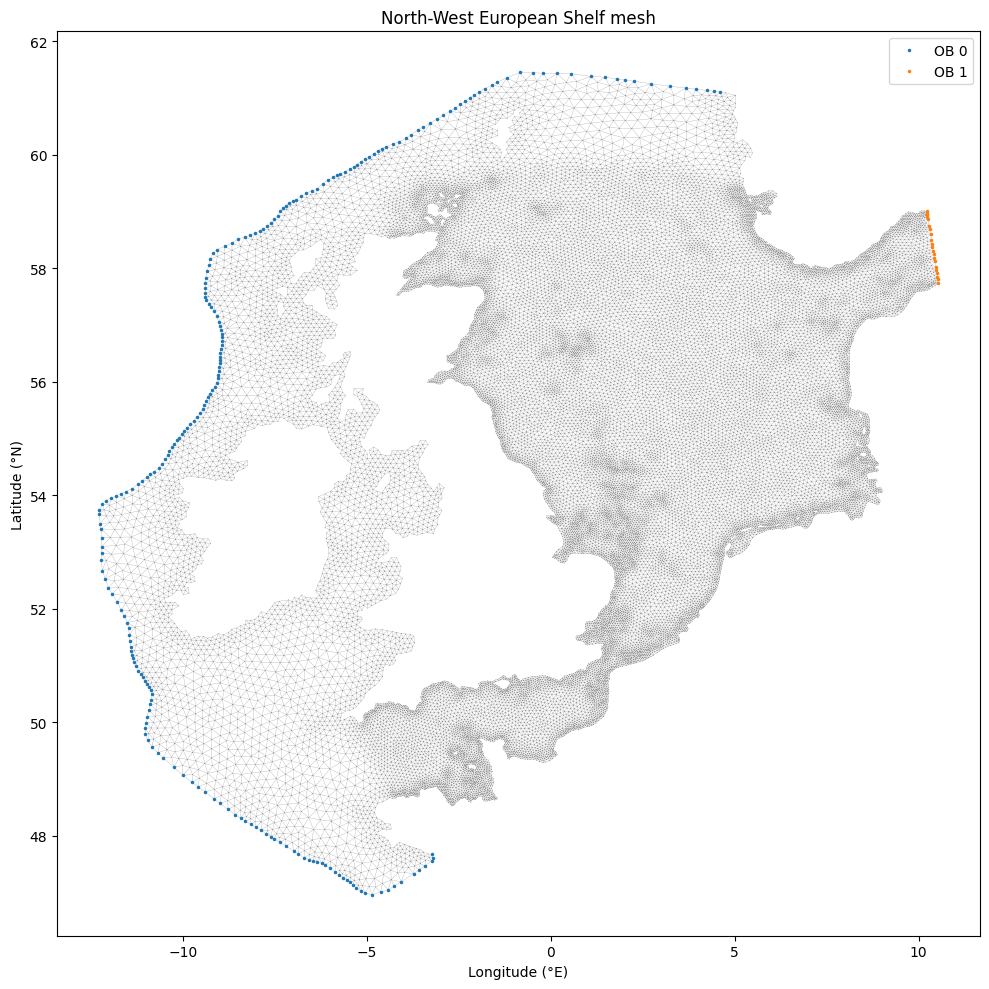

In [4]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.triplot(grid.lon_nodes, grid.lat_nodes, grid.triangles, linewidth=0.2, color='0.6')

colors = plt.cm.tab10.colors
for i, ob in enumerate(grid.open_boundaries):
    ax.plot(grid.lon_nodes[ob.node_indices], grid.lat_nodes[ob.node_indices],
            '.', color=colors[i % len(colors)], markersize=3,
            label=f'OB {i}')

ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.set_title('North-West European Shelf mesh')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Write the Grid and Depth Files

`write_grid` writes the FVCOM-format unstructured grid file. Passing `depth_file`
also produces a separate bathymetry file (used with the `GRID_DEPTH_FILE` namelist option).

In [5]:
grid.write_grid(out_grid, coordinate_system='geographic', depth_file=out_depth)
print(f'Written: {out_grid}')
print(f'Written: {out_depth}')

Written: /users/modellers/jcl/data/pyfvcom2_doc/FVCOM_north_sea/inputs/nsea_grd.dat
Written: /users/modellers/jcl/data/pyfvcom2_doc/FVCOM_north_sea/inputs/nsea_dep.dat


## 5. Write the Open Boundary File

The `obc.dat` file lists each open boundary node with its 1-based index and
boundary type. Type 1 is a simple tidal elevation boundary, which is what we
need for a tide-only run.

In [6]:
grid.write_obc(out_obc)
print(f'Written: {out_obc}')

n_obc = sum(ob.nnodes for ob in grid.open_boundaries)
print(f'Total OBC nodes: {n_obc}')

Written: /users/modellers/jcl/data/pyfvcom2_doc/FVCOM_north_sea/inputs/nsea_obc.dat
Total OBC nodes: 255


## 6. Write the Coriolis File

The Coriolis file provides the latitude at each node, from which FVCOM computes
the Coriolis parameter $f = 2\Omega \sin(\phi)$.

In [7]:
grid.write_coriolis(out_coriolis, coordinate_system='geographic')
print(f'Written: {out_coriolis}')

Written: /users/modellers/jcl/data/pyfvcom2_doc/FVCOM_north_sea/inputs/nsea_cor.dat


## 7. Write the Sigma Coordinate File

The sigma file defines the vertical layer distribution. Here we simply copy the
configuration that was read in with the grid — the sigma coordinate parameters
are stored on the `Grid` object.

In [8]:
grid.write_sigma(out_sigma)
print(f'Written: {out_sigma}')
print(f'Sigma type: {grid.sigma_config.sigtype}')
print(f'Levels:     {grid.n_sigma_levels}')

Written: /users/modellers/jcl/data/pyfvcom2_doc/FVCOM_north_sea/inputs/sigma_gen.dat
Sigma type: generalized
Levels:     25


## 8. Generate OBC Tidal Elevation Forcing

For a tide-only run, FVCOM needs a time series of sea surface elevation at
the open boundary nodes, constructed from tidal harmonics.

We use:
- `TPXOComplexHarmonicsReader` to read the TPXO atlas harmonic constituents
- `TPXOInterpolator` to interpolate harmonics onto the OBC node positions
- `TideManager` to reconstruct the tidal time series
- `OBCManager` to write the FVCOM OBC elevation forcing NetCDF file

### 8.1 Load TPXO harmonics

In [9]:
# Bounding box with a margin to ensure full coverage of the OBC nodes
bbox = (
    grid.lon_nodes.min() - 1.0, grid.lon_nodes.max() + 1.0,
    grid.lat_nodes.min() - 1.0, grid.lat_nodes.max() + 1.0,
)

h_reader   = TPXOComplexHarmonicsReader(tpxo_h_files)
h_var_names = get_tpxo_complex_harmonics_names('zeta')
h_harmonics = h_reader.read_harmonics(
    constituents, h_var_names,
    fill_land=True, bbox=bbox, bbox_margin=0.1
)
h_interpolator = TPXOInterpolator(h_harmonics)

print(f'Loaded {len(h_harmonics.constituents)} constituents: {h_harmonics.constituents}')

Loaded 6 constituents: ['M2', 'S2', 'K1', 'O1', 'N2', 'K2']


### 8.2 Build the TideManager and predict elevations

In [10]:
tide_manager = TideManager(constituents=constituents)
tide_manager.add_interpolator('zeta', h_interpolator)

obc_manager = OBCManager(grid)
obc_manager.set_dates(dates)
obc_manager.add_tidal_data(tide_manager)

print('Tidal predictions computed.')
print(f'  zeta shape: {obc_manager._zeta.shape}  (n_times × n_obc_nodes)')

prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... done.
prep/calcs ... done.
done.done.done.

prep/calcs ... prep/calcs ... done.done.prep/calcs ... 


done.prep/calcs ... done.prep/calcs ... prep/calcs ... 
prep/calcs ... 
prep/calcs ... done.
done.prep/calcs ... 
done.prep/calcs ... 
done.prep/calcs ... 
prep/calcs ... done.
done.prep/calcs ... done.
done.prep/calcs ... 

done.prep/calcs ... done.done.
prep/calcs ... 
prep/calcs ... 
prep/calcs ... done.prep/calcs ... 
done.prep/calcs ... done.

done.prep/calcs ... 
prep/calcs ... prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
done.done.prep/calcs ... 

done.done.done.done.prep/calcs ... 
prep/calcs ... done.



prep/calcs ... prep/calcs ... done.done.prep/calcs ... prep/calcs ... prep/calcs ... 

done.prep/calcs ... 
prep/calcs ... prep/calcs ... done.
prep/calcs ... done.
done.prep/calcs 

### 8.3 Write the forcing file

In [11]:
obc_manager.create_forcing_file(
    out_tides,
    ncopts={'zlib': True, 'complevel': 4},
)
print(f'Written: {out_tides}')
print(f'File size: {os.path.getsize(out_tides) / 1024:.1f} kB')

Written: /users/modellers/jcl/data/pyfvcom2_doc/FVCOM_north_sea/inputs/nsea_tides_obc.nc
File size: 699.4 kB


### 8.4 Visualise the predicted tides at a sample OBC node

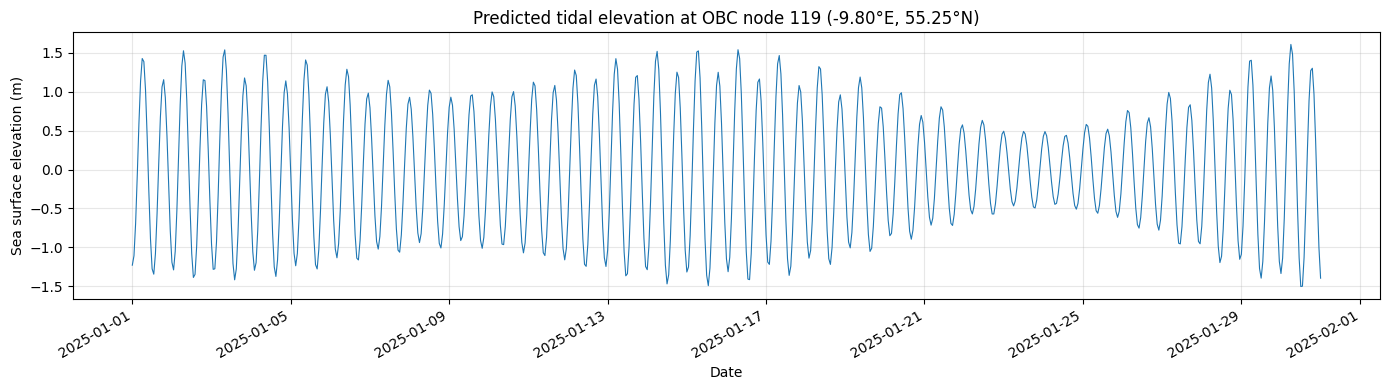

In [12]:
# Pick the midpoint of the first open boundary for illustration
sample_idx = len(grid.open_boundaries[0].node_indices) // 2
sample_node = grid.open_boundaries[0].node_indices[sample_idx]
sample_lon = grid.lon_nodes[sample_node]
sample_lat = grid.lat_nodes[sample_node]

zeta_sample = obc_manager._zeta[:, sample_idx]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates, zeta_sample, linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Sea surface elevation (m)')
ax.set_title(f'Predicted tidal elevation at OBC node {sample_node} '
             f'({sample_lon:.2f}°E, {sample_lat:.2f}°N)')
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 9. Summary

The following files have been written to `out_dir` and are ready to be referenced
in the FVCOM namelist for a tide-only run:

| File | Namelist key |
|---|---|
| `nsea_grd.dat` | `GRID_FILE` |
| `nsea_dep.dat` | `GRID_DEPTH_FILE` |
| `nsea_obc.dat` | `OBC_NODE_LIST` |
| `nsea_cor.dat` | `CORIOLIS_FILE` |
| `sigma_gen.dat` | `SIGMA_PARAMETER_FILE` |
| `nsea_tides_obc.nc` | `TIDAL_FORCING_FILE` |

Once FVCOM has run in tide-only mode and produced output, you can use
PyFVCOM2's harmonic analysis tools to extract tidal constituents and build
a harmonics file for use in a full baroclinic simulation with nest forcing.